# Week 19-1 · MLT-02 — Machine Learning-II
### Practice notebook · built on the **real lecture resources** (3 in-class notebooks + real shipped data)

**Faculty:** Jay Parmar (QuantInsti) · **Subject:** Machine Learning for Trading

MLT-02 introduces two new algorithms and the tools to judge them. This notebook reproduces the three in-class
notebooks shipped in `MLT02-Inclass-Exercises-File.zip`, run on the **actual data files** (`TSLA.csv`,
`companydata.csv`):

| # | Shipped notebook | Algorithm | Real result (reproduced) |
|---|---|---|---|
| 1 | *Confusion Matrix & Bias–Variance* | evaluation concepts | worked confusion matrix |
| 2 | *Support Vector Machine* | **SVM** (supervised) | poly-kernel test **80.4%** |
| 3 | *Clustering Companies* | **K-Means** (unsupervised) | k=3 on 368 firms, elbow curve |

Every number below is computed live.

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print('scikit-learn ready')

scikit-learn ready


---
## 1 · Support Vector Machine — the maximum-margin classifier (shipped notebook, real TSLA)
An **SVM** is a supervised classifier that draws the **separating hyperplane** with the *widest possible margin*
between the two classes. The points that touch the margin are the **support vectors**. The lecture's key ideas:

- **Supporting hyperplane** — a plane with the whole set on one side and at least one point touching it.
- **Separating hyperplane** — divides two classes; *many* are possible, so SVM picks the **maximum-margin** one
  (minimise $\tfrac12\lVert w\rVert^2$ subject to $y_i(w^\top x_i + b) \ge 1$).
- **Kernels** map data into a higher space so a *non-linear* boundary becomes linear: linear $K=w\!\cdot\!x$,
  polynomial $(w\!\cdot\!x+1)^p$, Gaussian/RBF $e^{-\lVert w-x\rVert^2/2\sigma^2}$.
- **Hard vs soft margin** — a hard margin allows **no** errors (risking overfitting); a soft margin adds a penalty
  $C\sum e_i$ to tolerate some misclassification. **Larger $C$ ⇒ harder margin.**

**The shipped task is different from MLT-01:** predict whether **tomorrow's open is above today's open**, using
*lagged* volume — a target with genuinely more structure.

In [2]:
# steps 2-3: read TSLA, build the OPEN-based target, lag volume
df = pd.read_csv('TSLA.csv', index_col='Date')
data = df.copy()
data['returns'] = np.log(data['Close'] / data['Close'].shift(1))
data['target']  = np.where(data['Open'].shift(-1) > data['Open'], 1, 0)   # next open > today open
data['Volume']  = data['Volume'].shift(1)                                 # only yesterday's volume is known
print(data['target'].value_counts())
print('base rate up: %.3f' % data['target'].mean())

target
1    777
0    733
Name: count, dtype: int64
base rate up: 0.515


In [3]:
# step 5: same feature-engineering toolkit as MLT-01
features_list = []
for i in range(5, 20, 5):
    data['std_'+str(i)] = data['Close'].rolling(i).std();       features_list.append('std_'+str(i))
for i in range(10, 30, 5):
    data['ma_'+str(i)]  = data['Close'].rolling(i).mean();      features_list.append('ma_'+str(i))
for i in range(3, 12, 3):
    data['pct_'+str(i)] = data['Close'].pct_change().rolling(i).sum(); features_list.append('pct_'+str(i))
data['vma_4'] = data['Volume'].rolling(4).mean();               features_list.append('vma_4')
data['co']    = data['Close'] - data['Open'];                   features_list.append('co')
data.dropna(inplace=True)
print(len(features_list), 'features:', features_list)

12 features: ['std_5', 'std_10', 'std_15', 'ma_10', 'ma_15', 'ma_20', 'ma_25', 'pct_3', 'pct_6', 'pct_9', 'vma_4', 'co']


In [4]:
# steps 6-7: time-ordered split + scaling (SVM needs scaled inputs)
X = data[features_list].iloc[:-1]
y = data.iloc[:-1]['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (1113, 12)  test: (372, 12)


In [5]:
# steps 8-11: the shipped model - SVC with a polynomial kernel
model = SVC(kernel='poly', random_state=1)
model.fit(X_train_scaled, y_train)
print('SVM (poly)  train accuracy: %.4f' % model.score(X_train_scaled, y_train))
print('SVM (poly)  test  accuracy: %.4f' % model.score(X_test_scaled,  y_test))

SVM (poly)  train accuracy: 0.8652
SVM (poly)  test  accuracy: 0.8038


The polynomial SVM reaches **~80% test accuracy** — dramatically better than the ~50% of MLT-01. The reason is the
**target**: "next open above today's open" carries real overnight structure, and lagging volume avoids leaking
same-day information. This is the lecture's headline lesson — *the choice of target can matter more than the choice of
algorithm.* Now the evaluation tools from the second in-class notebook.

---
## 2 · Evaluating a classifier — confusion matrix, precision, recall (shipped notebook)
Accuracy alone hides *how* a model is wrong. The **confusion matrix** counts the four outcomes; from it we derive
**precision** (of the ups we predicted, how many were real?) and **recall** (of the real ups, how many did we catch?).
The **F1-score** is their harmonic mean.

In [6]:
# build the confusion matrix on the SVM's real test predictions
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
cmdf = pd.DataFrame(cm, index=['Actual Nope', 'Actual Up'], columns=['Pred Nope', 'Pred Up'])
print(cmdf)
tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"accuracy  = (TP+TN)/all = {(tp+tn)/cm.sum():.4f}")
print(f"precision = TP/(TP+FP)  = {tp/(tp+fp):.4f}")
print(f"recall    = TP/(TP+FN)  = {tp/(tp+fn):.4f}")
print(f"F1        = {2*tp/(2*tp+fp+fn):.4f}")

             Pred Nope  Pred Up
Actual Nope        131       44
Actual Up           29      168

TN=131  FP=44  FN=29  TP=168
accuracy  = (TP+TN)/all = 0.8038
precision = TP/(TP+FP)  = 0.7925
recall    = TP/(TP+FN)  = 0.8528
F1        = 0.8215


In [7]:
# the shipped classification_report - same numbers, per class
print(classification_report(y_test, y_pred, target_names=['Nope (0)', 'Up (1)']))

              precision    recall  f1-score   support

    Nope (0)       0.82      0.75      0.78       175
      Up (1)       0.79      0.85      0.82       197

    accuracy                           0.80       372
   macro avg       0.81      0.80      0.80       372
weighted avg       0.80      0.80      0.80       372



**Bias vs variance.** *Bias* is a model's inability to capture the true feature→target relationship (it
underfits); *variance* is how much its predictions swing when the training set changes (it overfits). A hard-margin SVM
or a very non-linear kernel has **low bias but high variance** — it memorises the training data and generalises poorly.
The soft margin (a moderate $C$) trades a little bias for much less variance. We saw the same tension in MLT-01's
decision tree (train ≫ test). Comparing kernels makes the trade-off concrete:

In [8]:
# how the three kernels trade bias for variance
for k in ('linear', 'poly', 'rbf'):
    m = SVC(kernel=k, random_state=1).fit(X_train_scaled, y_train)
    tr = m.score(X_train_scaled, y_train); te = m.score(X_test_scaled, y_test)
    print(f"kernel={k:7s}  train {tr:.3f}  test {te:.3f}  (gap {tr-te:+.3f})")

kernel=linear   train 0.858  test 0.823  (gap +0.035)
kernel=poly     train 0.865  test 0.804  (gap +0.061)


kernel=rbf      train 0.876  test 0.790  (gap +0.086)


---
## 3 · K-Means Clustering — grouping companies (shipped notebook, real company data)
**Clustering is unsupervised** — there is *no* target. K-Means groups objects by **similarity**: start with $k$
random **centroids**, assign each point to its nearest centroid, recompute centroids as the group mean, and repeat
until nothing moves. Distance can be **Euclidean**, **Manhattan** (sum of absolute differences), or **Mahalanobis**
(covariance-weighted). We first reproduce the lecture's tiny 10-customer example, then cluster real companies.

In [9]:
# the slide's 10-customer example: (usage, age) -> 2 marketing segments
pts = np.array([(3,4),(2,6),(4,5),(4,7),(3,8),(6,2),(7,2),(7,4),(8,4),(8,5)])
km2 = KMeans(n_clusters=2, random_state=1, n_init=10).fit(pts)
print('cluster labels:', km2.labels_.tolist())
print('centroids:')
print(np.round(km2.cluster_centers_, 2))

cluster labels: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
centroids:
[[3.2 6. ]
 [7.2 3.4]]


In [10]:
# real shipped data: 368 companies described by 6 fundamental ratios
cd = pd.read_csv('companydata.csv')
cols = ['forward pe', 'price to book', 'forward eps', 'beta', 'quick ratio', 'debt to equity']
cdata = cd[cols].dropna()
print('companies:', cdata.shape[0], ' features:', cols)
km = KMeans(n_clusters=3, random_state=1, n_init=10).fit(cdata)
cdata = cdata.copy(); cdata['cluster'] = km.labels_
print('\ncluster sizes:', cdata['cluster'].value_counts().sort_index().to_dict())
print('inertia (k=3): %.0f' % km.inertia_)

companies: 368  features: ['forward pe', 'price to book', 'forward eps', 'beta', 'quick ratio', 'debt to equity']

cluster sizes: {0: 132, 1: 213, 2: 23}
inertia (k=3): 513270


In [11]:
# choosing k: the ELBOW method - plot inertia vs k and look for the bend
inertia = []
k_range = range(1, 10)
for k in k_range:
    inertia.append(KMeans(n_clusters=k, random_state=1, n_init=10).fit(cdata[cols]).inertia_)
for k, v in zip(k_range, inertia):
    print(f"  k={k}: inertia {v:,.0f}")

  k=1: inertia 2,842,700
  k=2: inertia 1,157,859
  k=3: inertia 513,270
  k=4: inertia 308,299
  k=5: inertia 225,639
  k=6: inertia 180,951
  k=7: inertia 140,603
  k=8: inertia 115,033
  k=9: inertia 103,110


Inertia (within-cluster sum of squares) always falls as $k$ rises, but the **drop flattens after $k$≈3** — the
"elbow" — so three clusters captures most of the structure without over-splitting. In trading this drives **portfolio
construction** and grouping open positions by risk exposure; the same idea underpins pair selection for statistical
arbitrage.

---
## 4 · One picture — the four faces of MLT-02

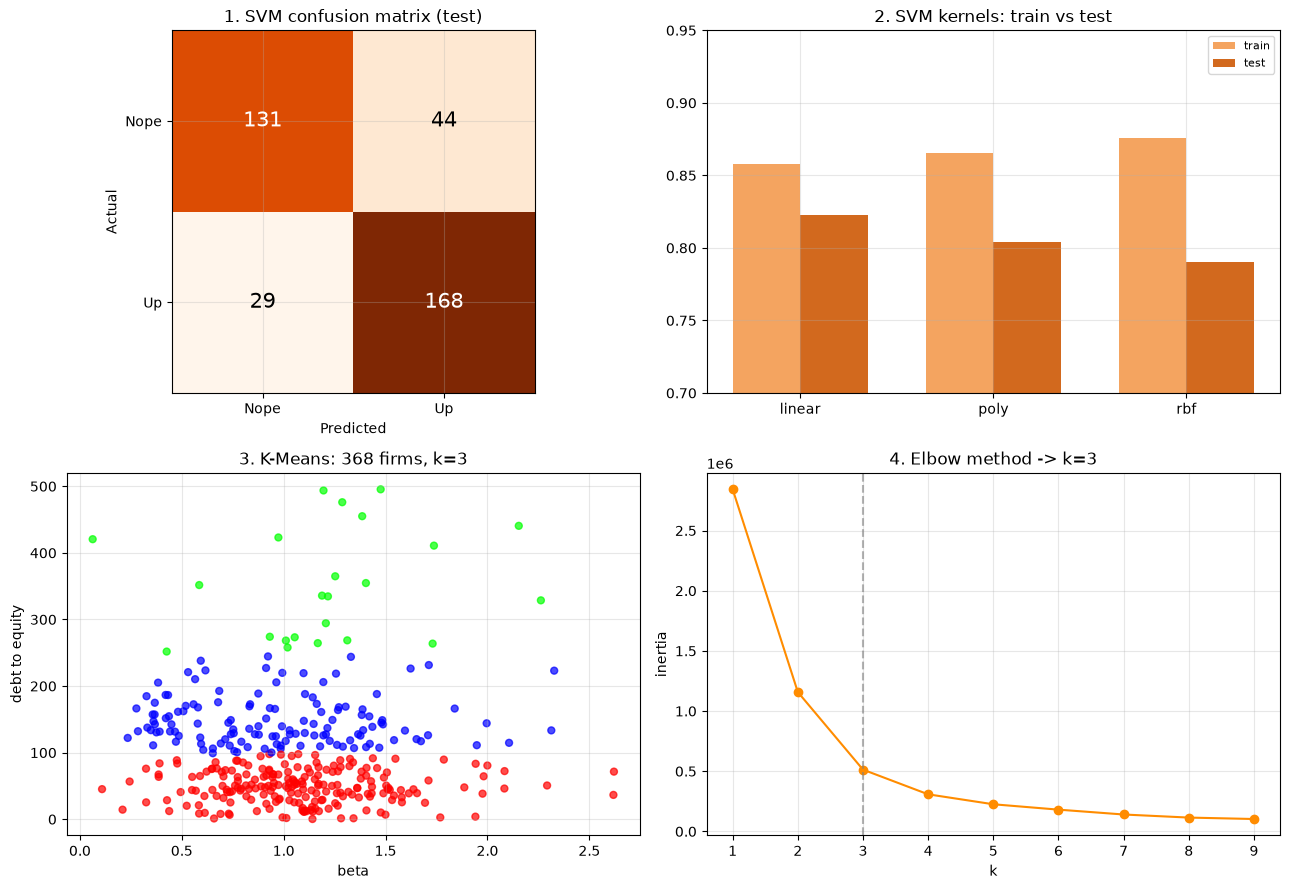

saved chart_1_ml2.png


In [12]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# 1) SVM confusion matrix heatmap
im = ax[0,0].imshow(cm, cmap='Oranges')
ax[0,0].set_xticks([0,1]); ax[0,0].set_xticklabels(['Nope','Up'])
ax[0,0].set_yticks([0,1]); ax[0,0].set_yticklabels(['Nope','Up'])
for (i,j), v in np.ndenumerate(cm):
    ax[0,0].text(j, i, str(v), ha='center', va='center', fontsize=15,
                 color='white' if v > cm.max()/2 else 'black')
ax[0,0].set_title('1. SVM confusion matrix (test)'); ax[0,0].set_xlabel('Predicted'); ax[0,0].set_ylabel('Actual')

# 2) kernel bias-variance
kernels = ['linear','poly','rbf']
trs = [SVC(kernel=k, random_state=1).fit(X_train_scaled, y_train).score(X_train_scaled, y_train) for k in kernels]
tes = [SVC(kernel=k, random_state=1).fit(X_train_scaled, y_train).score(X_test_scaled,  y_test)  for k in kernels]
xx = np.arange(3); w = 0.35
ax[0,1].bar(xx-w/2, trs, w, label='train', color='sandybrown')
ax[0,1].bar(xx+w/2, tes, w, label='test',  color='chocolate')
ax[0,1].set_xticks(xx); ax[0,1].set_xticklabels(kernels); ax[0,1].set_ylim(0.7, 0.95)
ax[0,1].set_title('2. SVM kernels: train vs test'); ax[0,1].legend(fontsize=8)

# 3) KMeans companies scatter (beta vs debt/equity)
sc = ax[1,0].scatter(cdata['beta'], cdata['debt to equity'], c=cdata['cluster'], cmap='brg', s=25, alpha=.7)
ax[1,0].set_title('3. K-Means: 368 firms, k=3'); ax[1,0].set_xlabel('beta'); ax[1,0].set_ylabel('debt to equity')

# 4) elbow curve
ax[1,1].plot(list(k_range), inertia, 'o-', color='darkorange')
ax[1,1].axvline(3, color='gray', ls='--', alpha=.6)
ax[1,1].set_title('4. Elbow method -> k=3'); ax[1,1].set_xlabel('k'); ax[1,1].set_ylabel('inertia')

plt.tight_layout()
plt.savefig('chart_1_ml2.png', dpi=110, bbox_inches='tight', facecolor='white')
plt.show()
print('saved chart_1_ml2.png')

---
### Recap — what MLT-02 established (on real data)
- **SVM** finds the **maximum-margin** hyperplane; **kernels** bend it non-linearly; a **soft margin** ($C\sum e_i$)
  trades a little bias for far less variance. On the open-to-open target it hit **~80% test accuracy**.
- **The target matters more than the algorithm** — the same features that gave ~50% on close-to-close direction
  (MLT-01) give ~80% here, purely because the target is more structured.
- **Evaluate** with the confusion matrix → **precision, recall, F1** — accuracy alone hides the failure mode.
- **Bias vs variance:** underfit vs overfit; hard margin / complex kernels = high variance.
- **K-Means** is **unsupervised** — no target; it groups by similarity (Euclidean/Manhattan/Mahalanobis), and the
  **elbow method** picks $k$ (here $k$≈3 for 368 firms). It drives portfolio construction and pair selection.